In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import math

In [2]:
G = nx.florentine_families_graph()

In [3]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 15
Number of edges: 20


In [4]:
degree_dict = dict(G.degree())
degrees = list(degree_dict.values())
density = nx.density(G)
components = list(nx.connected_components(G))

print("KEY METRICS")
print(f"Density: {density:.4f}")
print(f"Connected components: {len(components)}")
print(f"Minimum degree: {min(degrees)}")
print(f"Maximum degree: {max(degrees)}")
print(f"Average degree: {sum(degrees) / len(degrees):.2f}")

KEY METRICS
Density: 0.1905
Connected components: 1
Minimum degree: 1
Maximum degree: 6
Average degree: 2.67


In [5]:
metrics_table = pd.DataFrame({
    "Metric": [
        "Nodes",
        "Edges",
        "Density",
        "Connected Components",
        "Minimum Degree",
        "Maximum Degree",
        "Average Degree"
    ],
    "Value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        round(density, 4),
        len(components),
        min(degrees),
        max(degrees),
        round(sum(degrees) / len(degrees), 2)
    ]
})

print("MAIN METRICS TABLE")
print(metrics_table)

MAIN METRICS TABLE
                 Metric    Value
0                 Nodes  15.0000
1                 Edges  20.0000
2               Density   0.1905
3  Connected Components   1.0000
4        Minimum Degree   1.0000
5        Maximum Degree   6.0000
6        Average Degree   2.6700


In [6]:
degree_table = pd.DataFrame({
    "Family": list(degree_dict.keys()),
    "Degree": list(degree_dict.values())
}).sort_values(by="Degree", ascending=False)

print("DEGREE TABLE")
print(degree_table)

DEGREE TABLE
          Family  Degree
1         Medici       6
4        Strozzi       4
12      Guadagni       4
6        Ridolfi       3
3        Peruzzi       3
7     Tornabuoni       3
2     Castellani       3
11      Bischeri       3
8        Albizzi       3
9       Salviati       2
5      Barbadori       2
0     Acciaiuoli       1
10         Pazzi       1
13        Ginori       1
14  Lamberteschi       1


In [7]:
source = "Medici"
target = "Strozzi"
path = nx.shortest_path(G, source=source, target=target)

print("EXAMPLE PATH")
print(f"Shortest path from {source} to {target}:")
print(" -> ".join(path))

EXAMPLE PATH
Shortest path from Medici to Strozzi:
Medici -> Ridolfi -> Strozzi


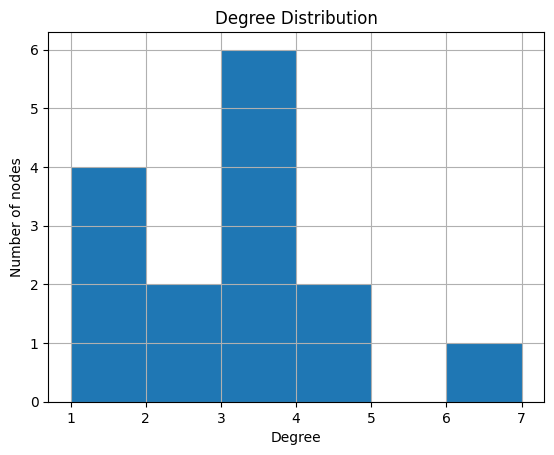

In [8]:
plt.figure()
plt.hist(degrees, bins=range(min(degrees), max(degrees)+2))
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.grid()
plt.show()

In [9]:
cycles = nx.cycle_basis(G)
example_cycle = cycles[0]

print("CYCLE")
print(" -> ".join(example_cycle + [example_cycle[0]]))

CYCLE
Peruzzi -> Strozzi -> Bischeri -> Peruzzi


In [10]:
print("ADJACENCY LIST")
for node in list(G.nodes())[:5]:
    print(f"{node}: {list(G.neighbors(node))}")

ADJACENCY LIST
Acciaiuoli: ['Medici']
Medici: ['Acciaiuoli', 'Barbadori', 'Ridolfi', 'Tornabuoni', 'Albizzi', 'Salviati']
Castellani: ['Peruzzi', 'Strozzi', 'Barbadori']
Peruzzi: ['Castellani', 'Strozzi', 'Bischeri']
Strozzi: ['Castellani', 'Peruzzi', 'Ridolfi', 'Bischeri']


In [11]:
nodes_subset = list(G.nodes())[:5]
adj_matrix = nx.to_pandas_adjacency(G, nodelist=nodes_subset, dtype=int)

print("ADJACENCY MATRIX")
print(adj_matrix)

ADJACENCY MATRIX
            Acciaiuoli  Medici  Castellani  Peruzzi  Strozzi
Acciaiuoli           0       1           0        0        0
Medici               1       0           0        0        0
Castellani           0       0           0        1        1
Peruzzi              0       0           1        0        1
Strozzi              0       0           1        1        0


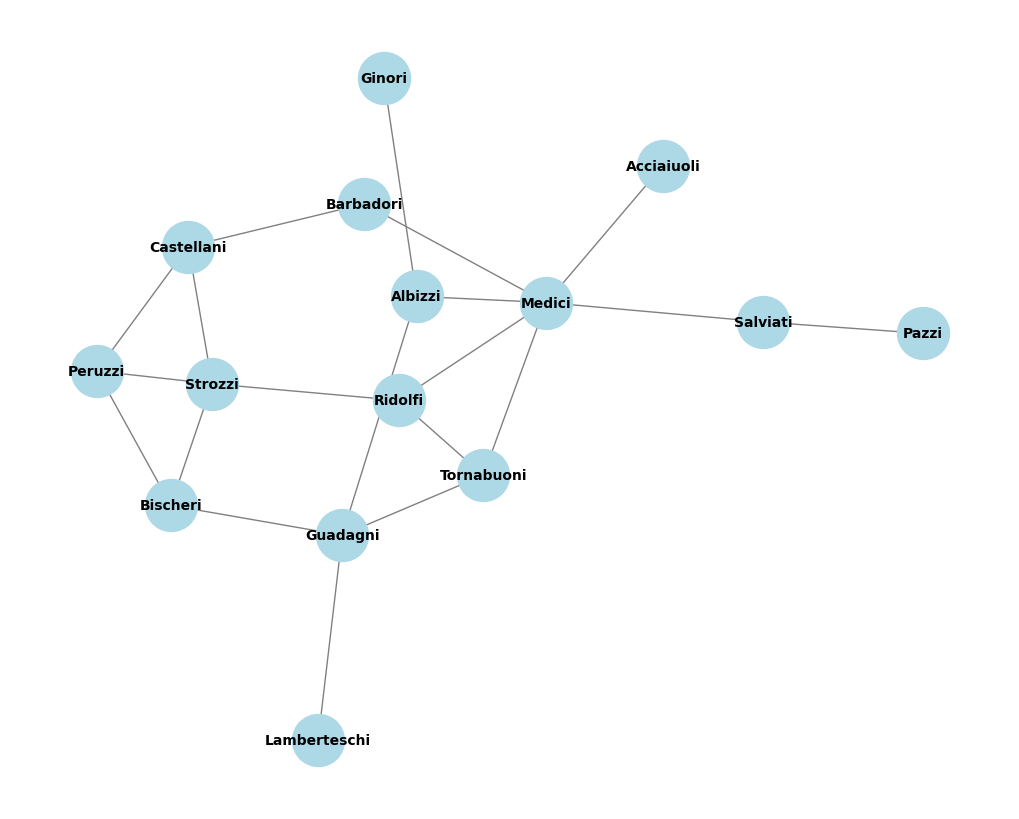

In [12]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=1400,
    edge_color="gray",
    font_size=10,
    font_weight="bold"
)

plt.show()

In [13]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
pagerank_centrality = nx.pagerank(G)

In [14]:
avg_clustering = nx.average_clustering(G)

diameter = nx.diameter(G)
avg_shortest_path = nx.average_shortest_path_length(G)

print(f"Average clustering: {avg_clustering:.3f}")
print(f"Diameter: {diameter}")
print(f"Average shortest path length: {avg_shortest_path:.3f}")

Average clustering: 0.160
Diameter: 5
Average shortest path length: 2.486


In [15]:
main_metrics = pd.DataFrame({
    "Metric": [
        "Nodes",
        "Edges",
        "Density",
        "Connected Components",
        "Minimum Degree",
        "Maximum Degree",
        "Average Degree",
        "Average Clustering",
        "Diameter",
        "Average Shortest Path Length"
    ],
    "Value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        round(nx.density(G), 4),
        len(list(nx.connected_components(G))),
        min(degrees),
        max(degrees),
        round(sum(degrees) / len(degrees), 2),
        round(avg_clustering, 4),
        diameter,
        round(avg_shortest_path, 4)
    ]
})

print("MAIN METRICS TABLE")
print(main_metrics)

MAIN METRICS TABLE
                         Metric    Value
0                         Nodes  15.0000
1                         Edges  20.0000
2                       Density   0.1905
3          Connected Components   1.0000
4                Minimum Degree   1.0000
5                Maximum Degree   6.0000
6                Average Degree   2.6700
7            Average Clustering   0.1600
8                      Diameter   5.0000
9  Average Shortest Path Length   2.4857


In [16]:
node_metrics = pd.DataFrame({
    "Family": list(G.nodes()),
    "Degree": [degree_dict[node] for node in G.nodes()],
    "Degree Centrality": [degree_centrality[node] for node in G.nodes()],
    "Betweenness Centrality": [betweenness_centrality[node] for node in G.nodes()],
    "Closeness Centrality": [closeness_centrality[node] for node in G.nodes()],
    "Eigenvector Centrality": [eigenvector_centrality[node] for node in G.nodes()],
    "PageRank": [pagerank_centrality[node] for node in G.nodes()]
}).round(4)

print("NODE METRICS")
print(node_metrics)

NODE METRICS
          Family  Degree  Degree Centrality  Betweenness Centrality  \
0     Acciaiuoli       1             0.0714                  0.0000   
1         Medici       6             0.4286                  0.5220   
2     Castellani       3             0.2143                  0.0549   
3        Peruzzi       3             0.2143                  0.0220   
4        Strozzi       4             0.2857                  0.1026   
5      Barbadori       2             0.1429                  0.0934   
6        Ridolfi       3             0.2143                  0.1136   
7     Tornabuoni       3             0.2143                  0.0916   
8        Albizzi       3             0.2143                  0.2125   
9       Salviati       2             0.1429                  0.1429   
10         Pazzi       1             0.0714                  0.0000   
11      Bischeri       3             0.2143                  0.1044   
12      Guadagni       4             0.2857                  0.2

In [17]:
top5 = node_metrics.sort_values(
    by="Betweenness Centrality", ascending=False
)[["Family", "Betweenness Centrality"]].head(5)

print(top5)
print()

      Family  Betweenness Centrality
1     Medici                  0.5220
12  Guadagni                  0.2546
8    Albizzi                  0.2125
9   Salviati                  0.1429
6    Ridolfi                  0.1136



In [18]:
top_degree = max(degree_dict, key=degree_dict.get)
top_betweenness = max(betweenness_centrality, key=betweenness_centrality.get)

print(f"Family with highest degree: {top_degree} ({degree_dict[top_degree]})")
print(f"Family with highest betweenness: {top_betweenness} ({betweenness_centrality[top_betweenness]:.4f})")

if top_degree == top_betweenness:
    print("Same family")
else:
    print("They are not the same family")

Family with highest degree: Medici (6)
Family with highest betweenness: Medici (0.5220)
Same family


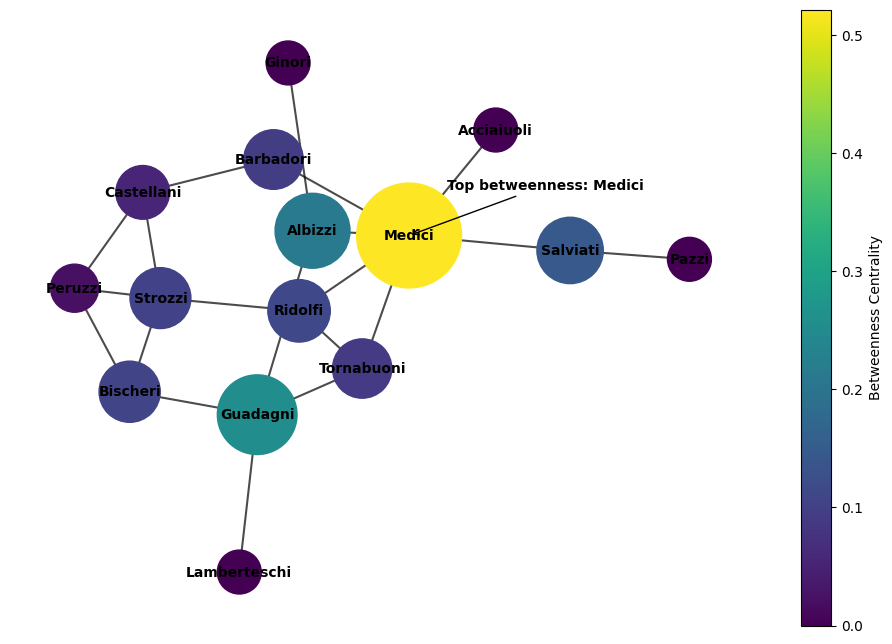

In [19]:
fig, ax = plt.subplots(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

node_sizes = [1000 + 9000 * betweenness_centrality[node] for node in G.nodes()]
node_colors = [betweenness_centrality[node] for node in G.nodes()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    ax=ax
)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=ax)

top_node = top_betweenness
x, y = pos[top_node]
ax.annotate(
    f"Top betweenness: {top_node}",
    xy=(x, y),
    xytext=(x + 0.1, y + 0.1),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
    fontweight="bold"
)

sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis,
    norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors))
)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Betweenness Centrality")

ax.axis("off")
plt.show()

Medici imaju najveći stupanj te imaju najviše veza. Te usput imaju najveću posredničku centralnost što predstavlja najvažniji most između drugih obitelji. Ukazuje na to da je obitelj vrlo ugledna i važna s velikim brojem veza.

Posrednička centralnost opisuje koliko je čvor važan kao most. Blizinska centralnost opisuje koliko je čvor blizu ostalim čvorovima u mreži. Svojstvena centralnost opisuje da važnost čvora ovisi o tome s kim je povezan. PageRank opisuje da jhe čvor važan ako je povezan s važnim čvorovima.

In [20]:
G_v04 = G.copy()

In [21]:
components = list(nx.connected_components(G_v04))
component_sizes = sorted([len(component) for component in components], reverse=True)
largest_component = len(max(components, key=len))

print("CONNECTED COMPONENTS")
print(f"Number of components: {len(components)}")
print(f"Sizes of components: {component_sizes}")
print(f"Largest component: {largest_component}")

CONNECTED COMPONENTS
Number of components: 1
Sizes of components: [15]
Largest component: 15


In [22]:
articulation_points = list(nx.articulation_points(G_v04))

print("ARTICULATION POINTS")
print(f"Articulation points ({len(articulation_points)}): {articulation_points}")

ARTICULATION POINTS
Articulation points (4): ['Albizzi', 'Guadagni', 'Medici', 'Salviati']


In [23]:
bridges = list(nx.bridges(G_v04))

print("BRIDGES")
print(f"Bridges ({len(bridges)}): {bridges}")

BRIDGES
Bridges (5): [('Acciaiuoli', 'Medici'), ('Medici', 'Salviati'), ('Albizzi', 'Ginori'), ('Salviati', 'Pazzi'), ('Guadagni', 'Lamberteschi')]


In [24]:
node_impact = []

for node in articulation_points:
    H = G_v04.copy()
    H.remove_node(node)

    new_components = list(nx.connected_components(H))
    new_component_sizes = sorted([len(component) for component in new_components], reverse=True)
    largest_component_after = len(max(new_components, key=len))

    node_impact.append({
        "removed_node": node,
        "components_after": len(new_components),
        "component_sizes_after": new_component_sizes,
        "largest_component_after": largest_component_after,
        "largest_component_drop": largest_component - largest_component_after
    })

node_impact = sorted(
    node_impact,
    key=lambda row: (row["components_after"], row["largest_component_drop"]),
    reverse=True
)

critical_node_result = node_impact[0]
critical_node = critical_node_result["removed_node"]

for row in node_impact:
    print(
        f"Remove {row['removed_node']}: "
        f"components={row['components_after']}, "
        f"sizes={row['component_sizes_after']}, "
        f"largest_component={row['largest_component_after']}"
    )

print(f"Critical node: {critical_node}")

G_after_node_removal = G_v04.copy()
G_after_node_removal.remove_node(critical_node)

components_after_node = list(nx.connected_components(G_after_node_removal))
component_sizes_after_node = sorted([len(component) for component in components_after_node], reverse=True)
largest_component_after_node = len(max(components_after_node, key=len))

print(f"Before removal: {len(components)} connected component(s), largest component = {largest_component}")
print(f"After removing {critical_node}: {len(components_after_node)} connected component(s), largest component = {largest_component_after_node}")
print(f"Component sizes after removing {critical_node}: {component_sizes_after_node}")

Remove Medici: components=3, sizes=[11, 2, 1], largest_component=11
Remove Albizzi: components=2, sizes=[13, 1], largest_component=13
Remove Guadagni: components=2, sizes=[13, 1], largest_component=13
Remove Salviati: components=2, sizes=[13, 1], largest_component=13
Critical node: Medici
Before removal: 1 connected component(s), largest component = 15
After removing Medici: 3 connected component(s), largest component = 11
Component sizes after removing Medici: [11, 2, 1]


In [25]:
edge_impact = []

for edge in bridges:
    H = G_v04.copy()
    H.remove_edge(*edge)

    new_components = list(nx.connected_components(H))
    new_component_sizes = sorted([len(component) for component in new_components], reverse=True)
    largest_component_after = len(max(new_components, key=len))

    edge_impact.append({
        "removed_edge": edge,
        "components_after": len(new_components),
        "component_sizes_after": new_component_sizes,
        "largest_component_after": largest_component_after,
        "largest_component_drop": largest_component - largest_component_after
    })

edge_impact = sorted(
    edge_impact,
    key=lambda row: (row["components_after"], row["largest_component_drop"]),
    reverse=True
)

critical_edge_result = edge_impact[0]
critical_edge = critical_edge_result["removed_edge"]

for row in edge_impact:
    print(
        f"Remove {row['removed_edge']}: "
        f"components={row['components_after']}, "
        f"sizes={row['component_sizes_after']}, "
        f"largest_component={row['largest_component_after']}"
    )

print(f"\nChosen critical edge: {critical_edge}")

G_after_edge_removal = G_v04.copy()
G_after_edge_removal.remove_edge(*critical_edge)

components_after_edge = list(nx.connected_components(G_after_edge_removal))
component_sizes_after_edge = sorted([len(component) for component in components_after_edge], reverse=True)
largest_component_after_edge = len(max(components_after_edge, key=len))

print(f"Before removal: {len(components)} connected component(s), largest component = {largest_component}")
print(f"After removing {critical_edge}: {len(components_after_edge)} connected component(s), largest component = {largest_component_after_edge}")
print(f"Component sizes after removing {critical_edge}: {component_sizes_after_edge}")

Remove ('Medici', 'Salviati'): components=2, sizes=[13, 2], largest_component=13
Remove ('Acciaiuoli', 'Medici'): components=2, sizes=[14, 1], largest_component=14
Remove ('Albizzi', 'Ginori'): components=2, sizes=[14, 1], largest_component=14
Remove ('Salviati', 'Pazzi'): components=2, sizes=[14, 1], largest_component=14
Remove ('Guadagni', 'Lamberteschi'): components=2, sizes=[14, 1], largest_component=14

Chosen critical edge: ('Medici', 'Salviati')
Before removal: 1 connected component(s), largest component = 15
After removing ('Medici', 'Salviati'): 2 connected component(s), largest component = 13
Component sizes after removing ('Medici', 'Salviati'): [13, 2]


In [26]:
node_drop_percent = ((largest_component - largest_component_after_node) / largest_component) * 100
edge_drop_percent = ((largest_component - largest_component_after_edge) / largest_component) * 100

print("RESILIENCE")
print(f"Node drop: {node_drop_percent:.2f}%")
print(f"Edge drop: {edge_drop_percent:.2f}%")


RESILIENCE
Node drop: 26.67%
Edge drop: 13.33%


Mreža na početku ima jednu povezanu komponentu, ali sadrži 4 artikulacijske točke i 5 mostova te ovisi o par poveznica. Najvažniji čvor je Medici sto vidimo iz njkegova uklanjanja kod broja komponenti raste s 1 na 3, a najveća komponenta pada s 15 na 11 čvorova. Najkritičniji brid je(Medici, Salviati), jer njegovim uklanjanjem broj komponenti raste na 2, a najveća komponenta pada na 13 čvorova. Što znači da mreža nema nema mnogo alternativnih veza te je osjetljiva je na gubitak nekoliko važnih obitelji i veza.

In [27]:
G_v05 = G_v04.copy()

In [28]:
louvain_partition = list(nx.community.louvain_communities(G_v05, seed=42))
louvain_partition = sorted(louvain_partition, key=len, reverse=True)

print("LOUVAIN COMMUNITIES")
print(f"Number of communities: {len(louvain_partition)}")

for i, community in enumerate(louvain_partition, start=1):
    print(f"Community {i} ({len(community)} nodes): {sorted(community)}")

LOUVAIN COMMUNITIES
Number of communities: 4
Community 1 (5 nodes): ['Acciaiuoli', 'Barbadori', 'Medici', 'Ridolfi', 'Tornabuoni']
Community 2 (4 nodes): ['Bischeri', 'Castellani', 'Peruzzi', 'Strozzi']
Community 3 (4 nodes): ['Albizzi', 'Ginori', 'Guadagni', 'Lamberteschi']
Community 4 (2 nodes): ['Pazzi', 'Salviati']


In [29]:
label_partition = list(nx.community.label_propagation_communities(G_v05))
label_partition = sorted(label_partition, key=len, reverse=True)

print("LABEL PROPAGATION COMMUNITIES")
print(f"Number of communities: {len(label_partition)}")

for i, community in enumerate(label_partition, start=1):
    print(f"Community {i} ({len(community)} nodes): {sorted(community)}")

LABEL PROPAGATION COMMUNITIES
Number of communities: 4
Community 1 (6 nodes): ['Barbadori', 'Bischeri', 'Castellani', 'Peruzzi', 'Ridolfi', 'Strozzi']
Community 2 (4 nodes): ['Acciaiuoli', 'Medici', 'Pazzi', 'Salviati']
Community 3 (3 nodes): ['Guadagni', 'Lamberteschi', 'Tornabuoni']
Community 4 (2 nodes): ['Albizzi', 'Ginori']


In [30]:
louvain_modularity = nx.community.modularity(G_v05, louvain_partition)
label_modularity = nx.community.modularity(G_v05, label_partition)

community_quality = pd.DataFrame({
    "Method": ["Louvain", "Label Propagation"],
    "Number of communities": [len(louvain_partition), len(label_partition)],
    "Modularity": [round(louvain_modularity, 4), round(label_modularity, 4)]
})

print("COMMUNITY QUALITY")
print(community_quality)

COMMUNITY QUALITY
              Method  Number of communities  Modularity
0            Louvain                      4      0.3975
1  Label Propagation                      4      0.3350


In [31]:
louvain_map = {}
for i, community in enumerate(louvain_partition, start=1):
    for node in community:
        louvain_map[node] = i

betweenness = nx.betweenness_centrality(G_v05)

bridge_nodes = []

for node in G_v05.nodes():
    neighbors = list(G_v05.neighbors(node))
    internal_neighbors = [n for n in neighbors if louvain_map[n] == louvain_map[node]]
    external_neighbors = [n for n in neighbors if louvain_map[n] != louvain_map[node]]

    if len(external_neighbors) > 0:
        bridge_nodes.append({
            "Family": node,
            "Community": louvain_map[node],
            "Internal links": len(internal_neighbors),
            "External links": len(external_neighbors),
            "External neighbors": ", ".join(sorted(external_neighbors)),
            "Betweenness Centrality": round(betweenness[node], 4)
        })

bridge_nodes_table = pd.DataFrame(bridge_nodes).sort_values(
    by=["External links", "Betweenness Centrality", "Family"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("BRIDGE NODES BETWEEN COMMUNITIES")
print(bridge_nodes_table)

top_bridge_nodes = bridge_nodes_table.head(3)["Family"].tolist()

print()
print(f"Main bridge nodes: {top_bridge_nodes}")

BRIDGE NODES BETWEEN COMMUNITIES
       Family  Community  Internal links  External links  \
0      Medici          1               4               2   
1    Guadagni          3               2               2   
2     Albizzi          3               2               1   
3    Salviati          4               1               1   
4     Ridolfi          1               2               1   
5    Bischeri          2               2               1   
6     Strozzi          2               3               1   
7   Barbadori          1               1               1   
8  Tornabuoni          1               2               1   
9  Castellani          2               2               1   

     External neighbors  Betweenness Centrality  
0     Albizzi, Salviati                  0.5220  
1  Bischeri, Tornabuoni                  0.2546  
2                Medici                  0.2125  
3                Medici                  0.1429  
4               Strozzi                  0.1136  
5     

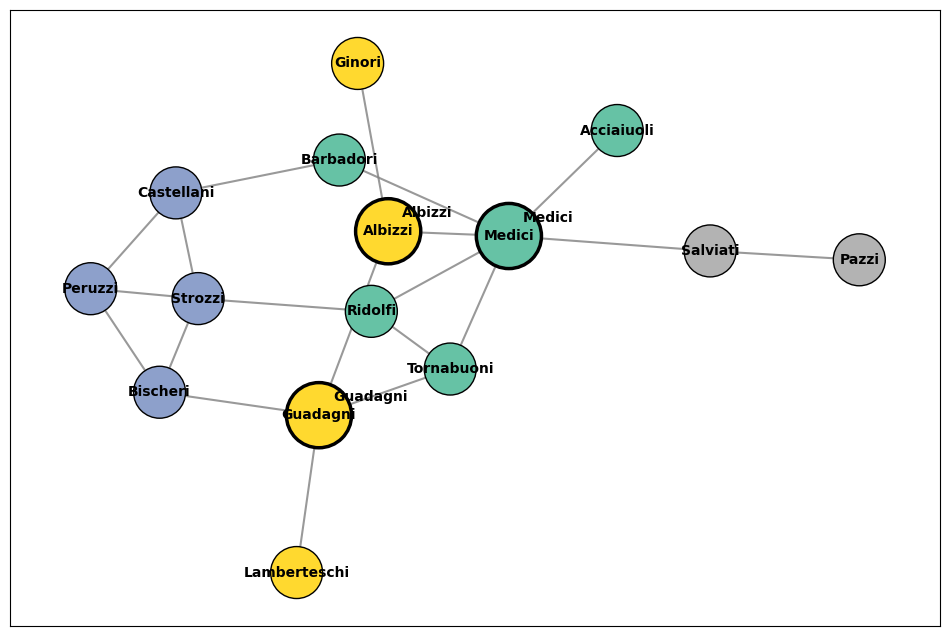

In [32]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_v05, seed=42)

community_colors = {}
for i, community in enumerate(louvain_partition):
    for node in community:
        community_colors[node] = i

node_colors = [community_colors[node] for node in G_v05.nodes()]
node_sizes = [2200 if node in top_bridge_nodes else 1400 for node in G_v05.nodes()]
node_linewidths = [2.5 if node in top_bridge_nodes else 1.0 for node in G_v05.nodes()]

nx.draw_networkx_nodes(
    G_v05,
    pos,
    node_color=node_colors,
    cmap=plt.cm.Set2,
    node_size=node_sizes,
    edgecolors="black",
    linewidths=node_linewidths
)

nx.draw_networkx_edges(
    G_v05,
    pos,
    edge_color="gray",
    width=1.5,
    alpha=0.8
)

nx.draw_networkx_labels(
    G_v05,
    pos,
    font_size=10,
    font_weight="bold"
)

for node in top_bridge_nodes:
    x, y = pos[node]
    plt.annotate(
        node,
        xy=(x, y),
        xytext=(x + 0.03, y + 0.03),
        fontsize=10,
        fontweight="bold"
    )
plt.show()

Zajednice predstavljaju skupine firentinskih obitelji koje su gušće povezane međusobno nego s ostatkom mreže. Louvain i Label propagation pokazuju da u mreži postoju odvojeni blokovi. Obitelji Medici i Guadagni se ističu kao mostovi između zajednica jer povezuju različite skupine. To znači da se politička struktura mreže oslanja na nekoliko važnih posrednika (Albizzi, Salviati, Ridolfi, Strozzi).

In [33]:
G_v06 = G_v05.copy()

In [34]:
n_vertices = G_v06.number_of_nodes()
M_edges = G_v06.number_of_edges()

G_er = nx.gnm_random_graph(
    n=n_vertices,
    m=M_edges,
    seed=42
)

print("ERDOS–RENYI")
print(f"Vertices: {G_er.number_of_nodes()}")
print(f"Edges: {G_er.number_of_edges()}")
print(f"Density: {nx.density(G_er):.4f}")

ERDOS–RENYI
Vertices: 15
Edges: 20
Density: 0.1905


In [35]:
normal_graph_degrees = [degree for node, degree in G_v06.degree()]
er_graph_degrees = [degree for node, degree in G_er.degree()]

normal_degree_frequency = {}
for degree in normal_graph_degrees:
    normal_degree_frequency[degree] = normal_degree_frequency.get(degree, 0) + 1

er_degree_frequency = {}
for degree in er_graph_degrees:
    er_degree_frequency[degree] = er_degree_frequency.get(degree, 0) + 1

all_degrees = sorted(
    set(normal_degree_frequency.keys()) | set(er_degree_frequency.keys())
)

degree_distribution_comparison = pd.DataFrame({
    "Degree": all_degrees,
    "Normal graph": [
        normal_degree_frequency.get(degree, 0)
        for degree in all_degrees
    ],
    "ER graph": [
        er_degree_frequency.get(degree, 0)
        for degree in all_degrees
    ]
})

print("DEGREE DISTRIBUTION")
print(degree_distribution_comparison)

DEGREE DISTRIBUTION
   Degree  Normal graph  ER graph
0       0             0         1
1       1             4         3
2       2             2         3
3       3             6         3
4       4             2         3
5       5             0         2
6       6             1         0


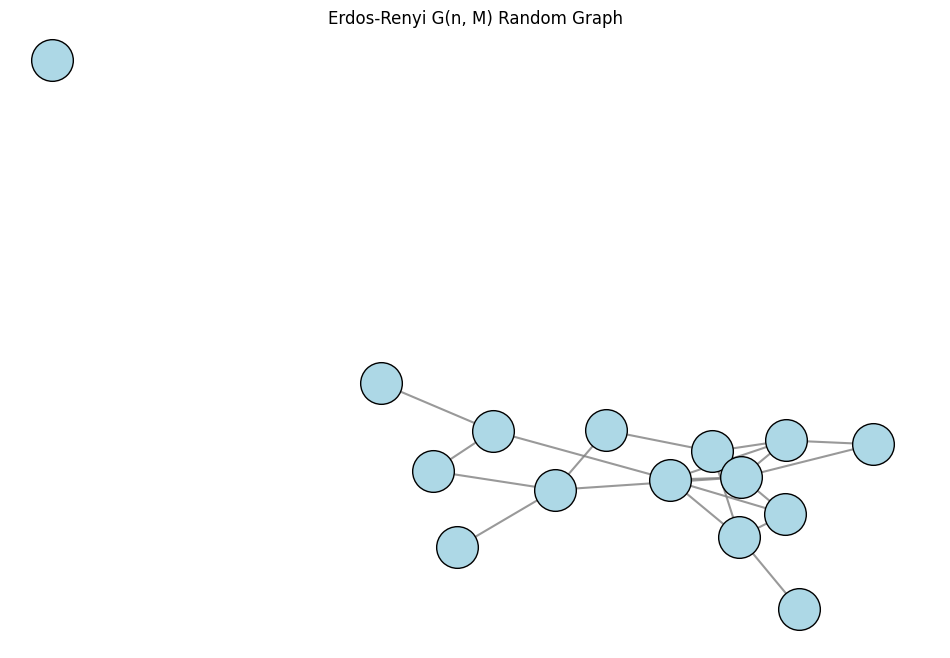

In [36]:
plt.figure(figsize=(12, 8))

er_position = nx.spring_layout(G_er, seed=42)

nx.draw_networkx_nodes(
    G_er,
    er_position,
    node_size=900,
    node_color="lightblue",
    edgecolors="black",
    linewidths=1
)

nx.draw_networkx_edges(
    G_er,
    er_position,
    edge_color="gray",
    width=1.5,
    alpha=0.8
)

plt.title("Erdos-Renyi G(n, M) Random Graph")
plt.axis("off")
plt.show()

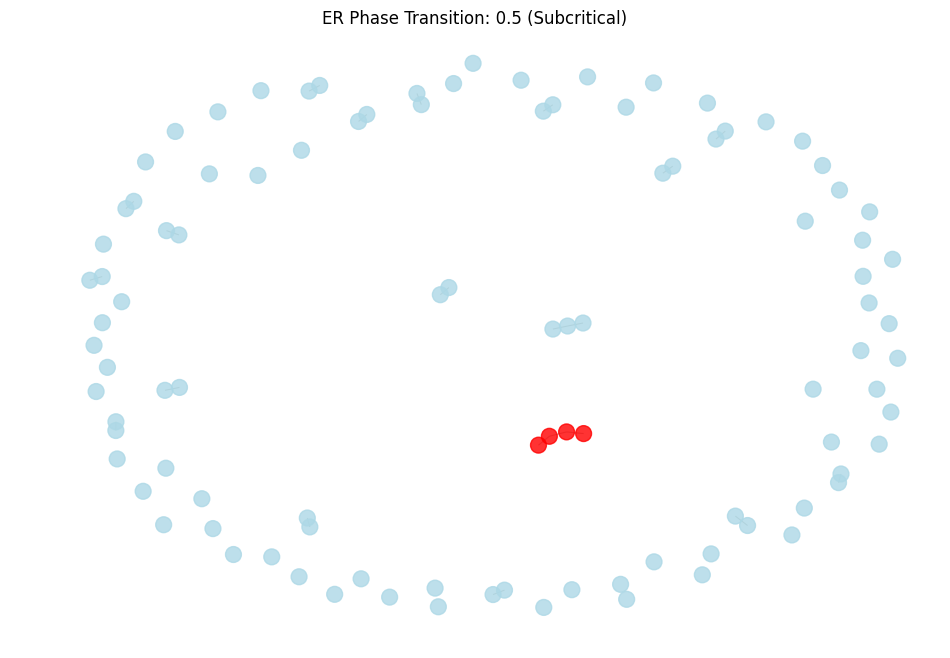

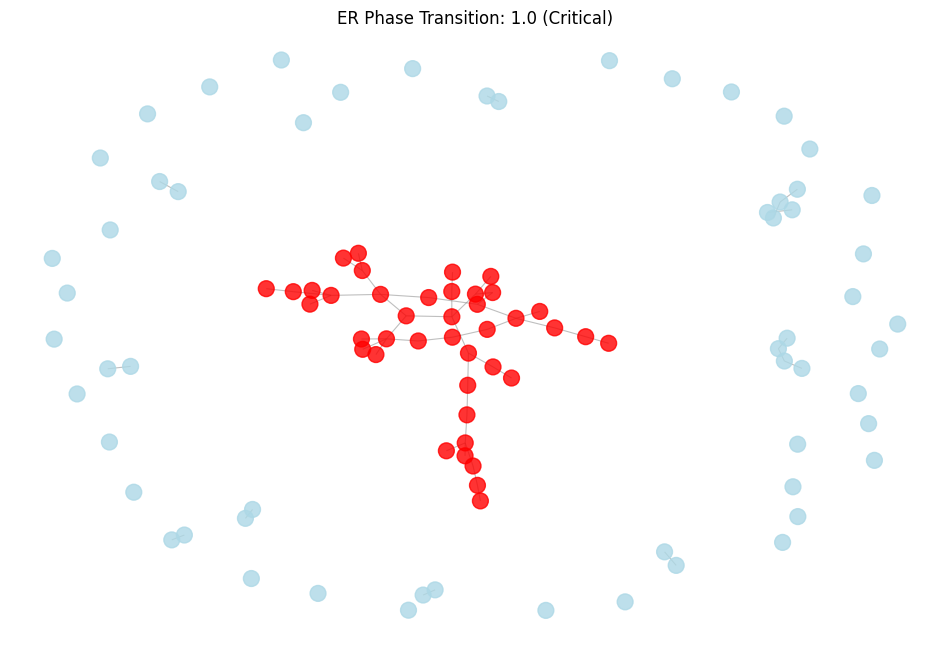

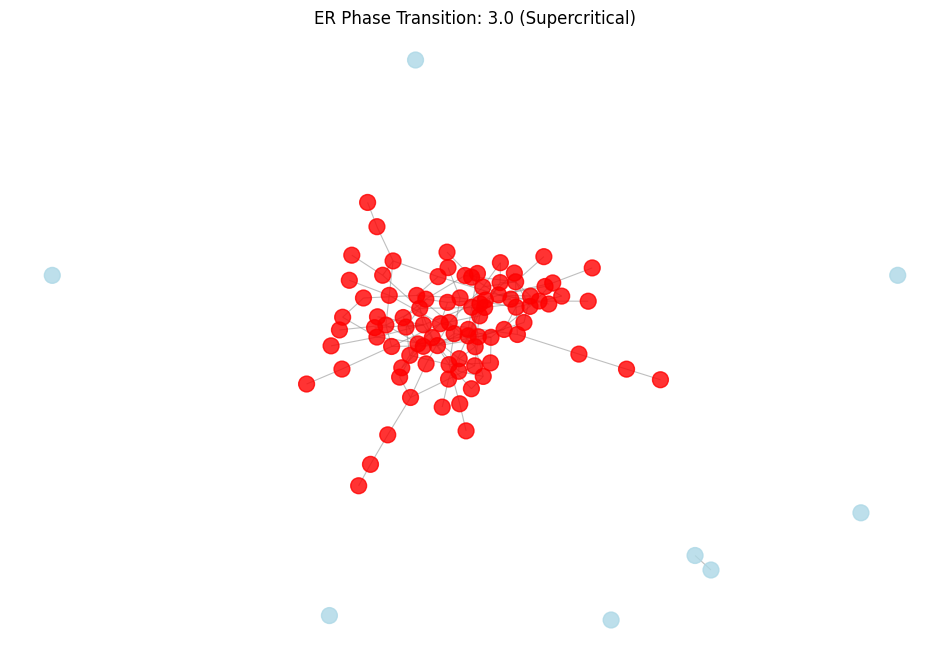

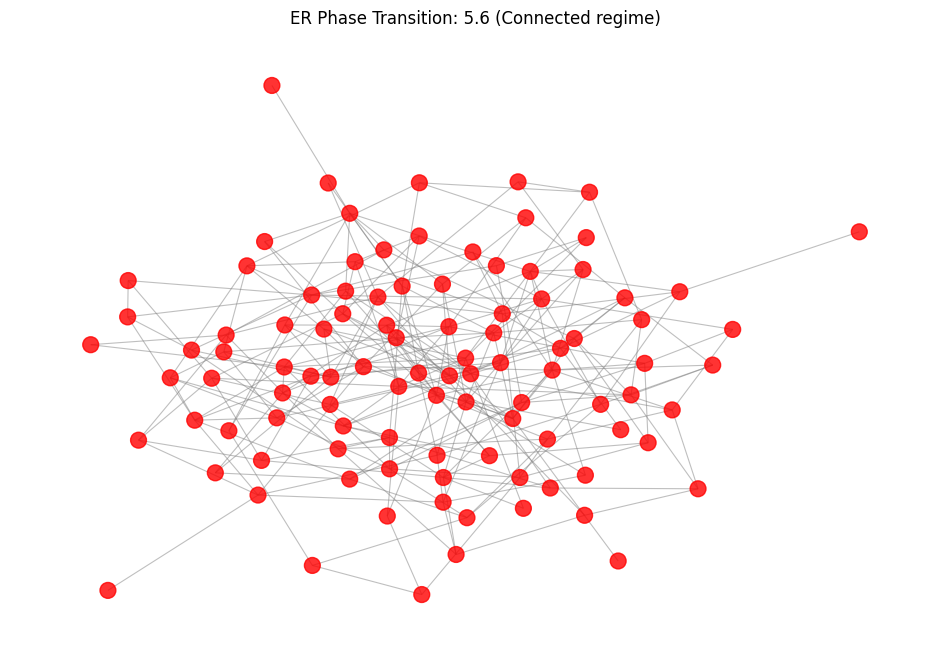

In [37]:
phase_transition_vertices = 100

phase_transition_stages = [
    (0.5, "Subcritical"),
    (1.0, "Critical"),
    (3.0, "Supercritical"),
    (math.log(phase_transition_vertices) + 1, "Connected regime")
]

for average_degree, stage_name in phase_transition_stages:
    edge_probability = average_degree / (phase_transition_vertices - 1)

    phase_graph = nx.erdos_renyi_graph(
        n=phase_transition_vertices,
        p=edge_probability,
        seed=42
    )

    largest_component_nodes = max(
        nx.connected_components(phase_graph),
        key=len
    )

    node_colors = [
        "red" if node in largest_component_nodes else "lightblue"
        for node in phase_graph.nodes()
    ]

    plt.figure(figsize=(12, 8))

    phase_position = nx.spring_layout(
        phase_graph,
        seed=42
    )

    nx.draw_networkx_nodes(
        phase_graph,
        phase_position,
        node_size=130,
        node_color=node_colors,
        alpha=0.8
    )

    nx.draw_networkx_edges(
        phase_graph,
        phase_position,
        edge_color="gray",
        width=0.8,
        alpha=0.5
    )

    plt.title(
        f"ER Phase Transition: {average_degree:.1f} ({stage_name})"
    )
    plt.axis("off")
    plt.show()

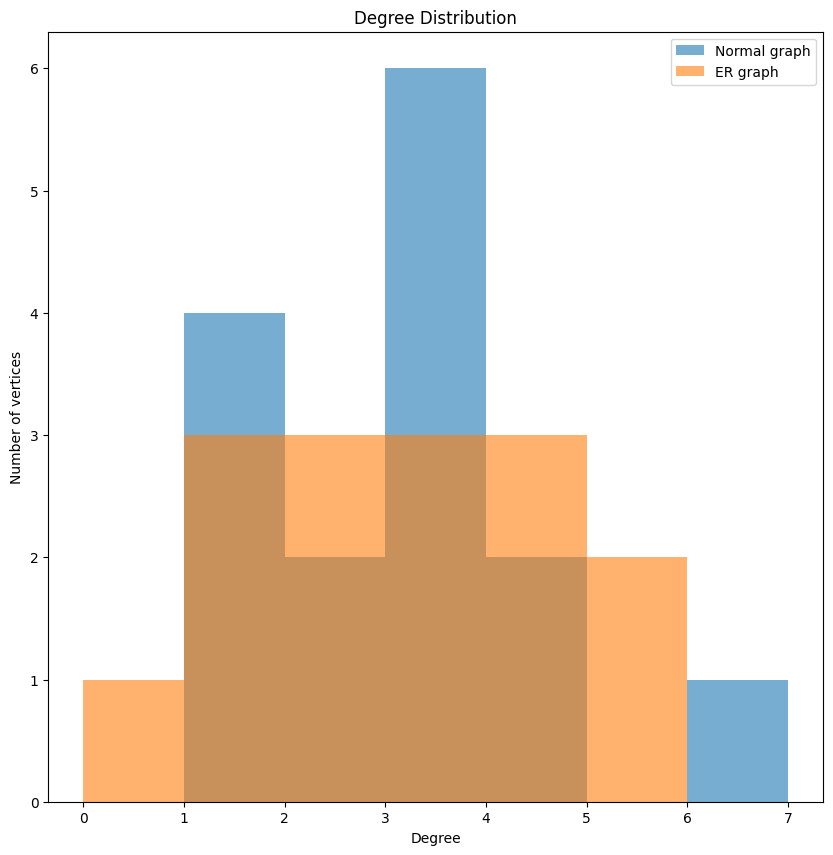

In [38]:
plt.figure(figsize=(10, 10))

max_degree_value = max(
    max(normal_graph_degrees),
    max(er_graph_degrees)
)

plt.hist(
    normal_graph_degrees,
    bins=range(0, max_degree_value + 2),
    alpha=0.6,
    label="Normal graph"
)

plt.hist(
    er_graph_degrees,
    bins=range(0, max_degree_value + 2),
    alpha=0.6,
    label="ER graph"
)

plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of vertices")
plt.legend()
plt.show()

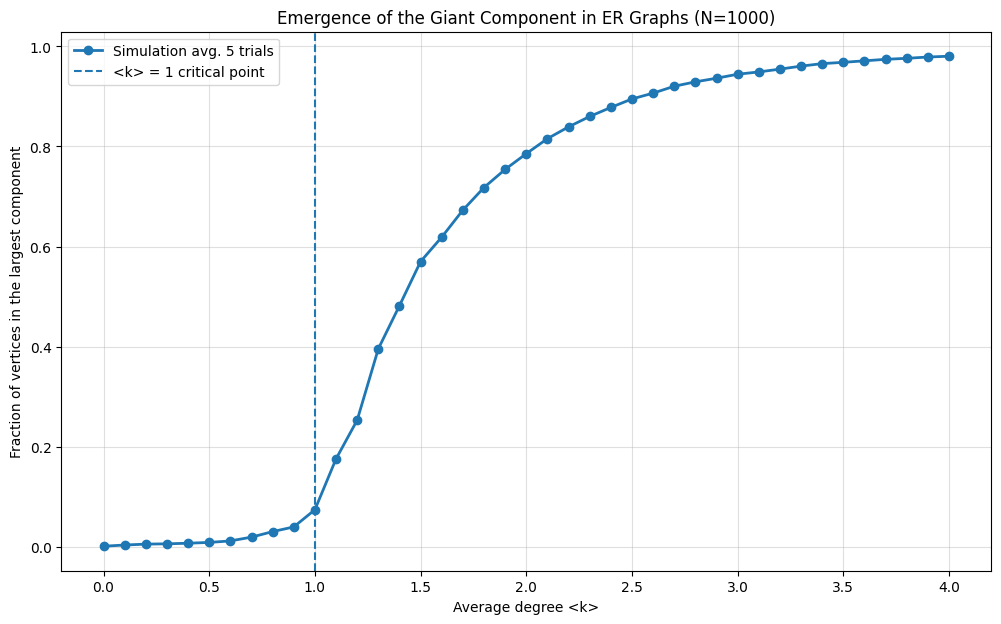

In [39]:
emergence_vertices = 1000
average_degrees_for_emergence = [i / 10 for i in range(0, 41)]
trials_per_average_degree = 5

largest_component_fractions = []

for average_degree in average_degrees_for_emergence:
    edge_probability = average_degree / (emergence_vertices - 1)

    trial_fractions = []

    for trial in range(trials_per_average_degree):
        emergence_graph = nx.erdos_renyi_graph(
            n=emergence_vertices,
            p=edge_probability,
            seed=trial
        )

        largest_component_size = len(
            max(nx.connected_components(emergence_graph), key=len)
        )

        largest_component_fraction = largest_component_size / emergence_vertices
        trial_fractions.append(largest_component_fraction)

    average_largest_component_fraction = sum(trial_fractions) / len(trial_fractions)
    largest_component_fractions.append(average_largest_component_fraction)

plt.figure(figsize=(12, 7))

plt.plot(
    average_degrees_for_emergence,
    largest_component_fractions,
    marker="o",
    linewidth=2,
    label="Simulation avg. 5 trials"
)

plt.axvline(
    x=1,
    linestyle="--",
    label="<k> = 1 critical point"
)

plt.title(
    f"Emergence of the Giant Component in ER Graphs (N={emergence_vertices})"
)
plt.xlabel("Average degree <k>")
plt.ylabel("Fraction of vertices in the largest component")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

In [40]:
normal_connected_components = list(nx.connected_components(G_v06))
normal_largest_component_nodes = max(normal_connected_components, key=len)
normal_largest_connected_component = G_v06.subgraph(normal_largest_component_nodes).copy()

er_connected_components = list(nx.connected_components(G_er))
er_largest_component_nodes = max(er_connected_components, key=len)
er_largest_connected_component = G_er.subgraph(er_largest_component_nodes).copy()

normal_average_clustering = nx.average_clustering(G_v06)
er_average_clustering = nx.average_clustering(G_er)

normal_average_path_length = nx.average_shortest_path_length(normal_largest_connected_component)
er_average_path_length = nx.average_shortest_path_length(er_largest_connected_component)

normal_largest_component_size = normal_largest_connected_component.number_of_nodes()
er_largest_component_size = er_largest_connected_component.number_of_nodes()

normal_maximum_degree = max(normal_graph_degrees)
er_maximum_degree = max(er_graph_degrees)

graph_comparison_table = pd.DataFrame({
    "Metric": [
        "Vertices",
        "Edges",
        "Density",
        "Average clustering coefficient",
        "Average path length on LCC",
        "Largest connected component size",
        "Maximum degree"
    ],
    "Normal graph": [
        G_v06.number_of_nodes(),
        G_v06.number_of_edges(),
        round(nx.density(G_v06), 4),
        round(normal_average_clustering, 4),
        round(normal_average_path_length, 4),
        normal_largest_component_size,
        normal_maximum_degree
    ],
    "ER graph": [
        G_er.number_of_nodes(),
        G_er.number_of_edges(),
        round(nx.density(G_er), 4),
        round(er_average_clustering, 4),
        round(er_average_path_length, 4),
        er_largest_component_size,
        er_maximum_degree
    ]
})

print("NORMAL GRAPH VS ER RANDOM GRAPH")
print(graph_comparison_table)

NORMAL GRAPH VS ER RANDOM GRAPH
                             Metric  Normal graph  ER graph
0                          Vertices       15.0000   15.0000
1                             Edges       20.0000   20.0000
2                           Density        0.1905    0.1905
3    Average clustering coefficient        0.1600    0.1844
4        Average path length on LCC        2.4857    2.3187
5  Largest connected component size       15.0000   14.0000
6                    Maximum degree        6.0000    5.0000


Stvarna mreža i ER graf imaju jednak broj vrhova i bridova, ali se razlikuju po strukturi povezivanja. U normalnoj mreži najveći stupanj iznosi 6 što kazuje da postoji izraženije najpovezaniji vrh nego u slučajnom grafu. Prosječna duljina puta je veća u normalnoj, dok je koeficijent klasteriranja u ER malo veći. Stvarna mreža pokazuje veću sveukupnost te izraženiji centralni vrh, dok ER graf prikazuje nasumičniju raspodjelu veza, pa usporedba pokazuje da dio strukture stvarne mreže nije posljedica slučaja (odnosno nije nastao samo nasumičnim povezivanjem vrhova, nego odražava stvarne obrasce odnosa među obiteljima)

In [41]:
G_v07 = G_v06.copy()

In [49]:
small_world_comparison_table = pd.DataFrame({
    "Metric": [
        "Average shortest path length",
        "Average clustering coefficient"
    ],
    "Normal graph": [
        round(normal_average_path_length, 4),
        round(normal_average_clustering, 4)
    ],
    "ER graph": [
        round(er_average_path_length, 4),
        round(er_average_clustering, 4)
    ]
})

print("SMALL-WORLD")
print(small_world_comparison_table)

SMALL-WORLD
                           Metric  Normal graph  ER graph
0    Average shortest path length        2.4857    2.3187
1  Average clustering coefficient        0.1600    0.1844


In [56]:
path_length_ratio = normal_average_path_length / er_average_path_length
clustering_ratio = normal_average_clustering / er_average_clustering

path_length_is_short = path_length_ratio <= 1.25
clustering_is_higher = normal_average_clustering > er_average_clustering

if path_length_is_short and clustering_ratio >= 1.5:
    small_world_result = "Small-world"
elif path_length_is_short and clustering_is_higher:
    small_world_result = "Partially small-world"
else:
    small_world_result = "Not small-world"

print("SMALL-WORLD")
print(f"Path length ratio Normal / ER: {path_length_ratio:.4f}")
print(f"Clustering ratio Normal / ER: {clustering_ratio:.4f}")
print(small_world_result)

SMALL-WORLD
Path length ratio Normal / ER: 1.0720
Clustering ratio Normal / ER: 0.8675
Not small-world


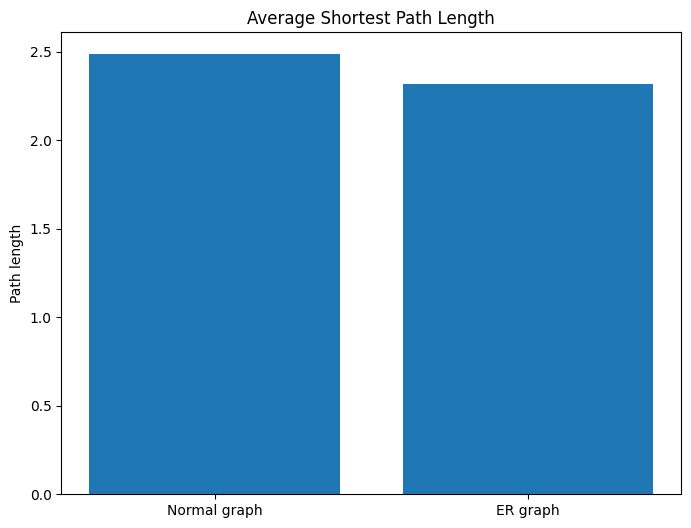

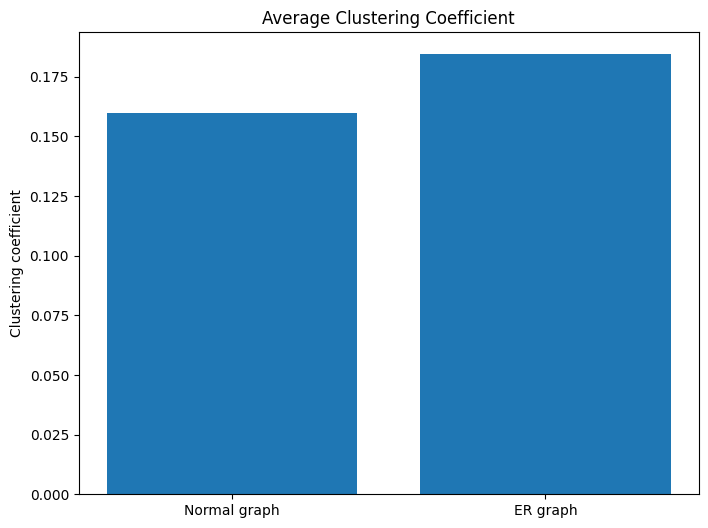

In [44]:
plt.figure(figsize=(8, 6))

plt.bar(
    ["Normal graph", "ER graph"],
    [normal_average_path_length, er_average_path_length]
)

plt.title("Average Shortest Path Length")
plt.ylabel("Path length")
plt.show()

plt.figure(figsize=(8, 6))

plt.bar(
    ["Normal graph", "ER graph"],
    [normal_average_clustering, er_average_clustering]
)

plt.title("Average Clustering Coefficient")
plt.ylabel("Clustering coefficient")
plt.show()

In [53]:
edge_betweenness_v07 = nx.edge_betweenness_centrality(G_v07)

shortcut_edges = []

for u, v in G_v07.edges():
    if louvain_map[u] != louvain_map[v]:
        shortcut_edges.append({
            "Edge": f"{u} - {v}",
            "First community": louvain_map[u],
            "Second community": louvain_map[v],
            "Edge betweenness centrality": round(edge_betweenness_v07[(u, v)], 4)
        })

shortcut_edges_table = pd.DataFrame(shortcut_edges).sort_values(
    by="Edge betweenness centrality",
    ascending=False
).reset_index(drop=True)

print("SHORTCUT EDGES")
print(shortcut_edges_table.head(2))

SHORTCUT EDGES
                Edge  First community  Second community  \
0  Medici - Salviati                1                 4   
1   Medici - Albizzi                1                 3   

   Edge betweenness centrality  
0                       0.2476  
1                       0.2127  


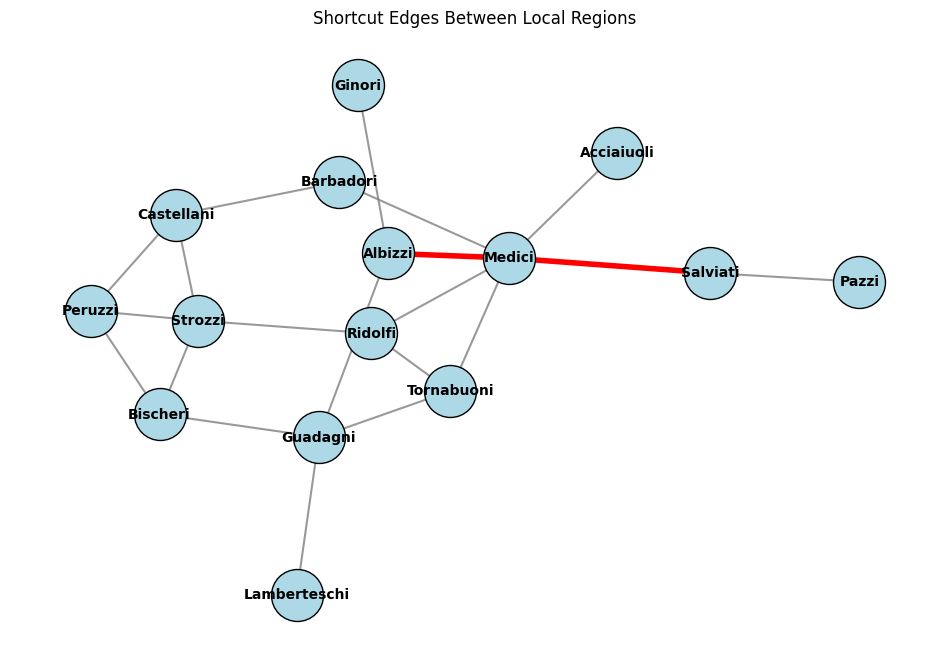

In [48]:
top_shortcut_edges = shortcut_edges_table.head(2)["Edge"].tolist()

top_shortcut_edge_pairs = []

for edge_label in top_shortcut_edges:
    first_node, second_node = edge_label.split(" - ")
    top_shortcut_edge_pairs.append((first_node, second_node))
plt.figure(figsize=(12, 8))

shortcut_position = nx.spring_layout(G_v07, seed=42)

nx.draw_networkx_nodes(
    G_v07,
    shortcut_position,
    node_color="lightblue",
    node_size=1400,
    edgecolors="black",
    linewidths=1.0
)

nx.draw_networkx_edges(
    G_v07,
    shortcut_position,
    edge_color="gray",
    width=1.5,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_v07,
    shortcut_position,
    edgelist=top_shortcut_edge_pairs,
    edge_color="red",
    width=4
)

nx.draw_networkx_labels(
    G_v07,
    shortcut_position,
    font_size=10,
    font_weight="bold"
)

plt.title("Shortcut Edges Between Local Regions")
plt.axis("off")
plt.show()

Mreža firentinskih obitelji nije small-world mreža. Prosječna duljina puta u mreži je 2.486 blizu ER grafu 2.3187 te su putevi relativno kratki. Prosječni koeficijent klasteriranja normalne mreže iznosi 0.1600 dok ER graf ima 0 što znači da stvarna mreža nema jače klasteriranje od slučajne mreže.Prečaci između regija su bridovi Medici-Salviati i Medici-Albizzi. Small-world djelomično odgovara mreži zbog kratkih puteva ali je nemozemo označiti kao small-world.